In [1]:
#Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
#Load and read file
clinic = pd.read_csv("messy_clinic_appointments.csv")
clinic.head(20)

,patient_id,patient_name,age,gender,appointment_date,booking_date,doctor,department,billing_amount,follow_up_required
0,1080,Tammy Williams,76,female,2026/02/26,2024/12/03,Christopher Graham,Cardiology,£425.8,1
1,1074,Megan Strickland,69,F,05/23/2025,12-Jun-2024,Brandon Lewis,Orthopedics,€344.26,Y
2,1067,Amanda Schroeder,79,M,30-Nov-2025,"August 05, 24",Deanna Edwards,Neurology,€203.34,Y
3,1072,Anthony Mcpherson,47,F,"May 18, 25",09/09/2024,Karen Parsons,General,Rs85.76,No
4,1092,Benjamin Brown,45,NaN,2026/03/07,08/17/2024,Andrea Hernandez,General,$84.44,1
5,1057,Joe Sharp,78,1,"September 26, 25",08/31/2025,Kimberly Fields,General,NaN,Yes
6,1018,Alexander Harris,22,Female,30-Oct-2025,12/29/2024,Jim Jones,Cardiology,€99.0,No
7,1074,Raymond Williams,57,M,2025/04/23,28-Mar-2025,James Brooks,Neurology,Rs374.63,No
8,1041,Dustin Willis,54,female,"August 22, 25",2024/11/07,Jamie Hill,General,$452.37,Yes
9,1011,Tina Gallagher,45,M,03/16/2026,12-Dec-2025,Tiffany Gates MD,Neurology,€494.97,Yes


In [3]:
#Create a copy of the dataset
clinic_copy = clinic.copy()

In [4]:
#Dataset information
clinic.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   patient_id          1000 non-null   int64
 1   patient_name        1000 non-null   str  
 2   age                 1000 non-null   int64
 3   gender              950 non-null    str  
 4   appointment_date    1000 non-null   str  
 5   booking_date        1000 non-null   str  
 6   doctor              1000 non-null   str  
 7   department          1000 non-null   str  
 8   billing_amount      950 non-null    str  
 9   follow_up_required  1000 non-null   str  
dtypes: int64(2), str(8)
memory usage: 146.4 KB


In [5]:
#Check for duplicates
clinic[clinic.duplicated()]

,patient_id,patient_name,age,gender,appointment_date,booking_date,doctor,department,billing_amount,follow_up_required


In [6]:
#Statistic information of the dataset
clinic.describe(include='all')

,patient_id,patient_name,age,gender,appointment_date,booking_date,doctor,department,billing_amount,follow_up_required
count,1000.000000,1000,1000.000000,950,1000,1000,1000,1000,950,1000
unique,NaN,988,NaN,8,735,822,990,4,949,6
top,NaN,Regina Wilson,NaN,0,2026/02/11,"August 05, 24",Jennifer Adams,Neurology,€243.78,0
freq,NaN,2,NaN,129,4,3,2,273,2,185
mean,1050.521000,NaN,53.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,28.888581,NaN,21.137604,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1000.000000,NaN,18.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,1025.000000,NaN,34.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,1051.000000,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1075.000000,NaN,71.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
#Check corresponding missing rows of a column
clinic[clinic["gender"].isna()]

,patient_id,patient_name,age,gender,appointment_date,booking_date,doctor,department,billing_amount,follow_up_required
4,1092,Benjamin Brown,45,NaN,2026/03/07,08/17/2024,Andrea Hernandez,General,$84.44,1
36,1003,Katelyn Smith,19,NaN,"October 16, 25",09/21/2025,Robert Henry,Neurology,$481.44,0
43,1063,Edward Sanders,29,NaN,2025/09/16,"April 29, 25",Steven Bailey,Orthopedics,Rs479.77,0
64,1077,Jennifer Stark,34,NaN,06/29/2025,04-Dec-2024,Jason Williams,Neurology,Rs270.33,N
70,1095,Jessica Heath,86,NaN,2025/06/25,04/24/2024,Sherri Long,Cardiology,€61.37,Yes
84,1093,Craig Nixon,55,NaN,2025/10/12,08/20/2025,William Key,Neurology,£341.19,No
91,1040,Chelsea Burns,62,NaN,"December 29, 25",13-May-2024,Michael Morales,Cardiology,Rs193.6,Yes
102,1088,Sarah Hahn,60,NaN,19-Mar-2026,2024/10/18,Theresa Lee,General,Rs123.03,Yes
108,1018,Monica Horton,53,NaN,11-Oct-2025,"March 30, 24",Kayla Stein,Neurology,$277.21,Yes
125,1053,John Johnson,81,NaN,23-Apr-2025,2024/12/30,Steve Bush,General,$162.94,N


In [8]:
#Check corresponding missing rows in the whole dataset
clinic[clinic.isnull().any(axis=1)]

,patient_id,patient_name,age,gender,appointment_date,booking_date,doctor,department,billing_amount,follow_up_required
4,1092,Benjamin Brown,45,NaN,2026/03/07,08/17/2024,Andrea Hernandez,General,$84.44,1
5,1057,Joe Sharp,78,1,"September 26, 25",08/31/2025,Kimberly Fields,General,NaN,Yes
33,1041,Nicole Shaw,20,male,05/07/2025,01/19/2025,Mr. Brian Morton,Neurology,NaN,Y
36,1003,Katelyn Smith,19,NaN,"October 16, 25",09/21/2025,Robert Henry,Neurology,$481.44,0
43,1063,Edward Sanders,29,NaN,2025/09/16,"April 29, 25",Steven Bailey,Orthopedics,Rs479.77,0
...,...,...,...,...,...,...,...,...,...,...
933,1034,Amanda Douglas,90,1,03/07/2026,2024/06/25,Gregory Gonzalez,General,NaN,0
937,1048,Ashley Black,84,F,05/29/2025,29-Jan-2025,Dennis Murphy,Neurology,NaN,N
938,1068,Wendy Parks,40,male,2026/02/14,09-Sep-2025,Melissa Williams,Neurology,NaN,1
956,1016,Jocelyn Strickland,22,M,30-Apr-2025,"July 10, 24",Vincent Kemp,Cardiology,NaN,N


In [9]:
#Data Preprocessing Stage.
#Remove the missing rows from the dataset
clinic.dropna(inplace=True)

In [10]:
#Cross-checking the dataset information for verification
clinic.info()

<class 'pandas.DataFrame'>
Index: 902 entries, 0 to 999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   patient_id          902 non-null    int64
 1   patient_name        902 non-null    str  
 2   age                 902 non-null    int64
 3   gender              902 non-null    str  
 4   appointment_date    902 non-null    str  
 5   booking_date        902 non-null    str  
 6   doctor              902 non-null    str  
 7   department          902 non-null    str  
 8   billing_amount      902 non-null    str  
 9   follow_up_required  902 non-null    str  
dtypes: int64(2), str(8)
memory usage: 140.1 KB


In [11]:
#Rename the follow_up_required column
clinic = clinic.rename(columns= {"follow_up_required":"follow_up"})

In [12]:
#Capitalize the column heads
clinic.columns = clinic.columns.str.replace("_"," ").str.title()

In [13]:
#Rename the patient id column
clinic = clinic.rename(columns= {"Patient Id":"Patient ID"})

In [14]:
#Better view of values under gender column
clinic["Gender"].unique()

<ArrowStringArray>
['female', 'F', 'M', 'Female', 'male', '1', 'Male', '0']
Length: 8, dtype: str

In [15]:
#Changing the gender values to male or female
clinic["Gender"] = clinic["Gender"].replace(["F","Female","0"],"female").replace(["M","Male","1"],"male")

In [16]:
#Better view of values under follow-up column
clinic["Follow Up"].unique()

<ArrowStringArray>
['1', 'Y', 'No', 'Yes', 'N', '0']
Length: 6, dtype: str

In [17]:
#View of the dataset to determine which class 0/1 belongs
clinic.sample(20) #Done 3x

,Patient ID,Patient Name,Age,Gender,Appointment Date,Booking Date,Doctor,Department,Billing Amount,Follow Up
410,1085,Jennifer Reese,62,female,"November 07, 25","August 11, 24",James Aguilar,Cardiology,£357.15,N
412,1066,Alexander Jones,85,female,2025/12/09,"January 30, 25",Mary Ward,General,Rs498.26,Y
313,1082,Dana Martinez,89,male,"March 27, 25",16-Dec-2024,Barry Bennett,Cardiology,Rs466.92,N
715,1013,Ashlee Warren,69,male,21-Jan-2026,06/01/2024,Cynthia Cruz,General,Rs289.74,1
518,1068,Dominic Bell,37,male,18-Nov-2025,2024/11/18,April Castillo,Cardiology,Rs356.13,Yes
756,1073,Curtis Cooke,84,male,09/29/2025,2024/06/24,John Hancock,Neurology,€477.08,No
740,1090,Christina Eaton,85,male,2026/01/20,"March 10, 25",Stephanie Kelley DVM,Neurology,$192.87,No
482,1002,Lawrence Ford,89,female,07/09/2025,2025/01/03,Randall Watts,Neurology,€167.8,Yes
252,1045,Brad West,34,female,05/14/2025,19-May-2024,Samuel Stone,Cardiology,£455.05,N
968,1036,Cameron Lopez,44,female,"April 27, 25",13-Dec-2024,Christopher Williams,Orthopedics,$163.0,Yes


In [18]:
#Change follow_up column values to yes or no
clinic["Follow Up"] = clinic["Follow Up"].replace(["1","Y","Yes"],"yes").replace(["0","N","No"],"no")

In [19]:
#Convert the booking and appointment date to datetime data type
clinic["Appointment Date"] = pd.to_datetime(clinic["Appointment Date"], format="mixed")
clinic["Booking Date"] = pd.to_datetime(clinic["Booking Date"], format="mixed")

In [20]:
#Create a new column for the billing amount that converts all currencies to the euros currency.
rates = {"GBP":1.1667,
         "USD": 0.8580,
         "INR": 0.0090,
         "EUR": 1.0000} #Define exchange rate

clinic["Billing Amount"] = clinic["Billing Amount"].str.strip() #Remove unnecessary space from the beginning and end

clinic["Currency"] = np.select([clinic["Billing Amount"].str.startswith("£"),
                                clinic["Billing Amount"].str.startswith("$"),
                                 clinic["Billing Amount"].str.startswith("Rs"),
                                  clinic["Billing Amount"].str.startswith("€")],["GBP","USD","INR","EUR"], default=pd.NA) #Create a currency column

clinic["Amount"] = clinic["Billing Amount"].str.replace(r"£|€|\$|Rs","",regex=True).str.strip() #Remove the currency symbol and create a new column

clinic["Amount"] = pd.to_numeric(clinic["Amount"], errors="coerce") #Convert to numeric data type

clinic["Amount Charge(€)"] = (clinic["Amount"] * clinic["Currency"].map(rates)).round(2) #Create a column that has the right conversion


In [21]:
#View of the dataset
clinic.sample(10)

,Patient ID,Patient Name,Age,Gender,Appointment Date,Booking Date,Doctor,Department,Billing Amount,Follow Up,Currency,Amount,Amount Charge(€)
78,1014,Amy Mayer,26,female,2025-09-28,2024-07-08,Jim Patterson,Cardiology,€253.4,yes,EUR,253.40,253.40
223,1091,Eric Allen,67,male,2025-08-01,2025-05-09,Amanda Mclaughlin,Neurology,£329.83,no,GBP,329.83,384.81
170,1083,Matthew Lloyd,58,male,2026-01-17,2025-07-21,Timothy Morgan,Cardiology,€244.78,no,EUR,244.78,244.78
610,1008,Darryl Murphy,82,male,2026-03-03,2024-11-03,Christian Chapman,Cardiology,€207.23,no,EUR,207.23,207.23
723,1030,Brandon Carter,72,female,2025-05-10,2025-02-27,James Aguilar,Neurology,£218.54,no,GBP,218.54,254.97
105,1027,Benjamin Hughes,32,female,2026-03-02,2025-12-17,Nicholas Mcneil,Cardiology,£125.31,yes,GBP,125.31,146.20
932,1012,Gregory Hines,76,male,2026-02-07,2026-01-15,Rebecca Goodwin,Orthopedics,Rs255.43,no,INR,255.43,2.30
659,1016,Ryan Rodriguez,53,female,2025-05-29,2025-02-22,Eric Kennedy,Orthopedics,Rs277.5,yes,INR,277.50,2.50
776,1066,Jonathan Wood,74,female,2025-05-23,2024-12-26,Jon Duarte,Orthopedics,Rs486.07,yes,INR,486.07,4.37
868,1092,Tiffany Cooper,58,male,2025-07-05,2025-05-16,Katrina Jones,General,€79.8,yes,EUR,79.80,79.80


In [22]:
#Arrange column in a presiding logical order
logical_order = ["Patient ID","Patient Name","Age","Gender","Booking Date","Appointment Date","Doctor","Department","Billing Amount","Currency","Amount","Amount Charge(€)","Follow Up"]

clinic = clinic[logical_order]

In [23]:
#Cross-checking the dataset information for verification
clinic.info()

<class 'pandas.DataFrame'>
Index: 902 entries, 0 to 999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Patient ID        902 non-null    int64         
 1   Patient Name      902 non-null    str           
 2   Age               902 non-null    int64         
 3   Gender            902 non-null    str           
 4   Booking Date      902 non-null    datetime64[us]
 5   Appointment Date  902 non-null    datetime64[us]
 6   Doctor            902 non-null    str           
 7   Department        902 non-null    str           
 8   Billing Amount    902 non-null    str           
 9   Currency          902 non-null    str           
 10  Amount            902 non-null    float64       
 11  Amount Charge(€)  902 non-null    float64       
 12  Follow Up         902 non-null    str           
dtypes: datetime64[us](2), float64(2), int64(2), str(7)
memory usage: 146.7 KB


In [24]:
#Statistical information of the dataset
clinic.describe(include='all')

,Patient ID,Patient Name,Age,Gender,Booking Date,Appointment Date,Doctor,Department,Billing Amount,Currency,Amount,Amount Charge(€),Follow Up
count,902.000000,902,902.000000,902,902,902,902,902,902,902,902.000000,902.000000,902
unique,NaN,892,NaN,2,NaN,NaN,892,4,901,4,NaN,NaN,2
top,NaN,Regina Wilson,NaN,female,NaN,NaN,Jennifer Adams,Neurology,€243.78,INR,NaN,NaN,yes
freq,NaN,2,NaN,460,NaN,NaN,2,245,2,237,NaN,NaN,463
mean,1050.514412,NaN,53.684035,NaN,2025-01-03 05:43:14.235033,2025-10-03 03:22:44.966740,NaN,NaN,NaN,NaN,275.726364,202.680310,NaN
min,1000.000000,NaN,18.000000,NaN,2024-03-26 00:00:00,2025-03-26 00:00:00,NaN,NaN,NaN,NaN,51.380000,0.500000,NaN
25%,1025.250000,NaN,34.250000,NaN,2024-08-16 06:00:00,2025-07-06 00:00:00,NaN,NaN,NaN,NaN,163.100000,4.322500,NaN
50%,1051.000000,NaN,55.000000,NaN,2024-12-26 00:00:00,2025-10-12 00:00:00,NaN,NaN,NaN,NaN,269.140000,189.065000,NaN
75%,1075.000000,NaN,71.000000,NaN,2025-05-13 00:00:00,2025-12-30 00:00:00,NaN,NaN,NaN,NaN,387.707500,342.197500,NaN
max,1100.000000,NaN,90.000000,NaN,2026-03-07 00:00:00,2026-03-26 00:00:00,NaN,NaN,NaN,NaN,499.750000,582.960000,NaN


In [25]:
#Feature Engineering Stage.
#Create column for days between the booking and appointment date
clinic["Waiting Days"] = (clinic["Appointment Date"] - clinic["Booking Date"]).dt.days

In [26]:
"""From the statistic view, patient name and doctor column has the same uniques values. Is it the same patient with the same doctor, do they assign back to the same doctor once you have booked before? A question that arise due to the iterative process between feature engineering and EDA.

Answer/Observation: The doctor is not to the same patient, and the patients age difference are much for a gap of two years."""

'From the statistic view, patient name and doctor column has the same uniques values. Is it the same patient with the same doctor, do they assign back to the same doctor once you have booked before? A question that arise due to the iterative process between feature engineering and EDA.\n\nAnswer/Observation: The doctor is not to the same patient, and the patients age difference are much for a gap of two years.'

In [27]:
#For the patient name column duplicate
patient_duplicate = clinic[clinic["Patient Name"].duplicated(keep=False)].sort_values(by=["Patient Name"],ascending=False)
patient_duplicate

,Patient ID,Patient Name,Age,Gender,Booking Date,Appointment Date,Doctor,Department,Billing Amount,Currency,Amount,Amount Charge(€),Follow Up,Waiting Days
273,1054,Thomas Smith,82,male,2024-12-07,2025-11-23,Kenneth Turner,Cardiology,Rs392.87,INR,392.87,3.54,yes,351
435,1067,Thomas Smith,54,female,2025-09-05,2025-09-11,Brandon Garcia,Cardiology,$108.91,USD,108.91,93.44,no,6
50,1040,Regina Wilson,26,male,2024-06-03,2025-08-14,Jenny Zuniga,Cardiology,Rs185.66,INR,185.66,1.67,yes,437
784,1095,Regina Wilson,73,male,2024-12-14,2025-12-31,Heidi Hamilton,Neurology,£275.12,GBP,275.12,320.98,yes,382
615,1077,Pamela Davis,78,female,2025-09-15,2025-12-19,Antonio Galloway,Orthopedics,€320.38,EUR,320.38,320.38,yes,95
772,1005,Pamela Davis,27,female,2024-04-12,2025-11-23,Kevin Fields,General,€57.05,EUR,57.05,57.05,yes,590
434,1027,Michael Sullivan,63,male,2024-07-31,2025-07-09,Angela Thomas,Orthopedics,Rs318.88,INR,318.88,2.87,yes,343
998,1088,Michael Sullivan,65,female,2024-04-15,2025-07-04,Anthony Mccoy,Neurology,$434.95,USD,434.95,373.19,no,445
73,1022,Katelyn Miller,23,female,2024-09-16,2026-02-19,Andrea Cruz,Orthopedics,$382.34,USD,382.34,328.05,yes,521
396,1070,Katelyn Miller,78,male,2024-11-25,2025-12-19,Justin Chen,Cardiology,Rs274.94,INR,274.94,2.47,no,389


In [28]:
#For the doctor column duplicate
doctor_duplicate = clinic[clinic["Doctor"].duplicated(keep=False)].sort_values(by=["Doctor"],ascending=False)
doctor_duplicate

,Patient ID,Patient Name,Age,Gender,Booking Date,Appointment Date,Doctor,Department,Billing Amount,Currency,Amount,Amount Charge(€),Follow Up,Waiting Days
199,1050,William Lewis,32,male,2024-05-16,2025-04-04,Wesley Johnson,Orthopedics,Rs361.31,INR,361.31,3.25,yes,323
808,1067,Benjamin Ramirez,57,female,2025-01-06,2025-12-22,Wesley Johnson,Neurology,$142.33,USD,142.33,122.12,no,350
577,1016,Heidi Sosa,29,male,2025-05-17,2025-11-10,Nancy Wilson,Cardiology,Rs241.81,INR,241.81,2.18,yes,177
978,1088,Kevin Peters,19,female,2025-04-28,2025-07-23,Nancy Wilson,General,€96.78,EUR,96.78,96.78,no,86
113,1086,Harry Wallace,80,female,2024-10-28,2025-12-01,Nancy Hernandez,Orthopedics,$493.0,USD,493.00,422.99,yes,399
348,1033,Michele Green,48,female,2025-01-24,2025-06-30,Nancy Hernandez,Orthopedics,Rs88.58,INR,88.58,0.80,no,157
315,1088,Kimberly Robinson,26,female,2025-12-28,2026-03-04,Michael Wright,Cardiology,Rs71.67,INR,71.67,0.65,no,66
960,1035,John Marsh,33,male,2024-06-04,2025-05-04,Michael Wright,General,£407.7,GBP,407.70,475.66,yes,334
510,1038,Ashley Wright,45,female,2025-06-03,2026-02-26,Kristen Lopez,General,€403.22,EUR,403.22,403.22,yes,268
970,1081,William Hatfield,32,male,2025-04-14,2026-02-26,Kristen Lopez,Neurology,$112.79,USD,112.79,96.77,no,318


In [29]:
#Drop columns not needed
clinic = clinic.drop(columns=["Patient ID", "Patient Name", "Billing Amount", "Currency", "Amount"])

In [30]:
#Arrange column in a presiding logical order again
logical_order = ["Age","Gender","Department","Doctor","Amount Charge(€)","Booking Date","Appointment Date","Waiting Days","Follow Up"]

clinic = clinic[logical_order]

In [31]:
#Cross-checking the dataset information for verification
clinic.info()

<class 'pandas.DataFrame'>
Index: 902 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Age               902 non-null    int64         
 1   Gender            902 non-null    str           
 2   Department        902 non-null    str           
 3   Doctor            902 non-null    str           
 4   Amount Charge(€)  902 non-null    float64       
 5   Booking Date      902 non-null    datetime64[us]
 6   Appointment Date  902 non-null    datetime64[us]
 7   Waiting Days      902 non-null    int64         
 8   Follow Up         902 non-null    str           
dtypes: datetime64[us](2), float64(1), int64(2), str(4)
memory usage: 97.1 KB


In [32]:
#Scaling
clinic["Department"].unique() #View of the unique values under the department column.

<ArrowStringArray>
['Cardiology', 'Orthopedics', 'Neurology', 'General']
Length: 4, dtype: str

In [33]:
#Mapping
clinic["Follow Up"] = clinic["Follow Up"].map({"no":0, "yes":1})
clinic["Gender"] = clinic["Gender"].map({"male":0, "female":1})
clinic["Department"] = clinic["Department"].map({"Cardiology":1, "General":2, "Neurology":3, "Orthopedics":4})

In [34]:
#Cross-checking the dataset information for verification
clinic.info()

<class 'pandas.DataFrame'>
Index: 902 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Age               902 non-null    int64         
 1   Gender            902 non-null    int64         
 2   Department        902 non-null    int64         
 3   Doctor            902 non-null    str           
 4   Amount Charge(€)  902 non-null    float64       
 5   Booking Date      902 non-null    datetime64[us]
 6   Appointment Date  902 non-null    datetime64[us]
 7   Waiting Days      902 non-null    int64         
 8   Follow Up         902 non-null    int64         
dtypes: datetime64[us](2), float64(1), int64(5), str(1)
memory usage: 82.1 KB


In [35]:
#Encoding: frequency encoding for high-cardinality
frequency_encode = clinic["Doctor"].value_counts()
clinic["Doctor Frequency"] = clinic["Doctor"].map(frequency_encode)

In [36]:
#Arrange column in a presiding logical order again
logical_order = ["Age","Gender","Department","Doctor","Doctor Frequency","Amount Charge(€)","Booking Date","Appointment Date","Waiting Days","Follow Up"]

clinic = clinic[logical_order]

In [37]:
#Cross-checking the dataset information for verification
clinic.info()

<class 'pandas.DataFrame'>
Index: 902 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Age               902 non-null    int64         
 1   Gender            902 non-null    int64         
 2   Department        902 non-null    int64         
 3   Doctor            902 non-null    str           
 4   Doctor Frequency  902 non-null    int64         
 5   Amount Charge(€)  902 non-null    float64       
 6   Booking Date      902 non-null    datetime64[us]
 7   Appointment Date  902 non-null    datetime64[us]
 8   Waiting Days      902 non-null    int64         
 9   Follow Up         902 non-null    int64         
dtypes: datetime64[us](2), float64(1), int64(6), str(1)
memory usage: 89.2 KB


In [38]:
#Statistical information of the dataset
clinic.describe(include='all')

,Age,Gender,Department,Doctor,Doctor Frequency,Amount Charge(€),Booking Date,Appointment Date,Waiting Days,Follow Up
count,902.000000,902.000000,902.000000,902,902.000000,902.000000,902,902,902.000000,902.000000
unique,NaN,NaN,NaN,892,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,Jennifer Adams,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN
mean,53.684035,0.509978,2.545455,NaN,1.022173,202.680310,2025-01-03 05:43:14.235033,2025-10-03 03:22:44.966740,272.902439,0.513304
min,18.000000,0.000000,1.000000,NaN,1.000000,0.500000,2024-03-26 00:00:00,2025-03-26 00:00:00,2.000000,0.000000
25%,34.250000,0.000000,2.000000,NaN,1.000000,4.322500,2024-08-16 06:00:00,2025-07-06 00:00:00,127.500000,0.000000
50%,55.000000,1.000000,3.000000,NaN,1.000000,189.065000,2024-12-26 00:00:00,2025-10-12 00:00:00,256.000000,1.000000
75%,71.000000,1.000000,4.000000,NaN,1.000000,342.197500,2025-05-13 00:00:00,2025-12-30 00:00:00,394.750000,1.000000
max,90.000000,1.000000,4.000000,NaN,2.000000,582.960000,2026-03-07 00:00:00,2026-03-26 00:00:00,728.000000,1.000000


<Figure size 1000x1000 with 0 Axes>

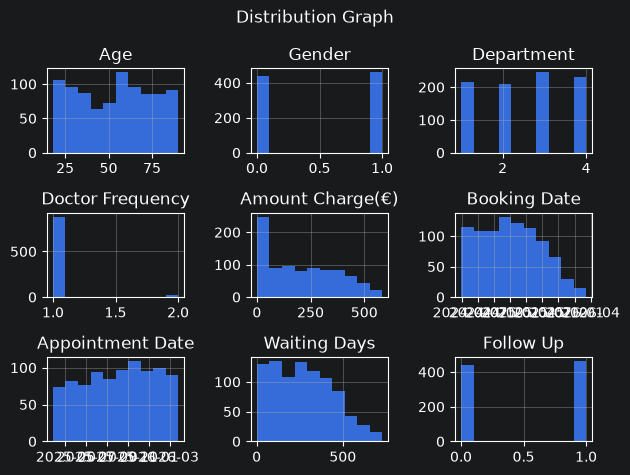

In [39]:
#EDA Stage.
#Univariant analysis; histogram graph for distribution
plt.figure(figsize=(10,10))#Size of the plot.
clinic.hist()
plt.suptitle("Distribution Graph", fontsize=12)
plt.tight_layout()
plt.show();

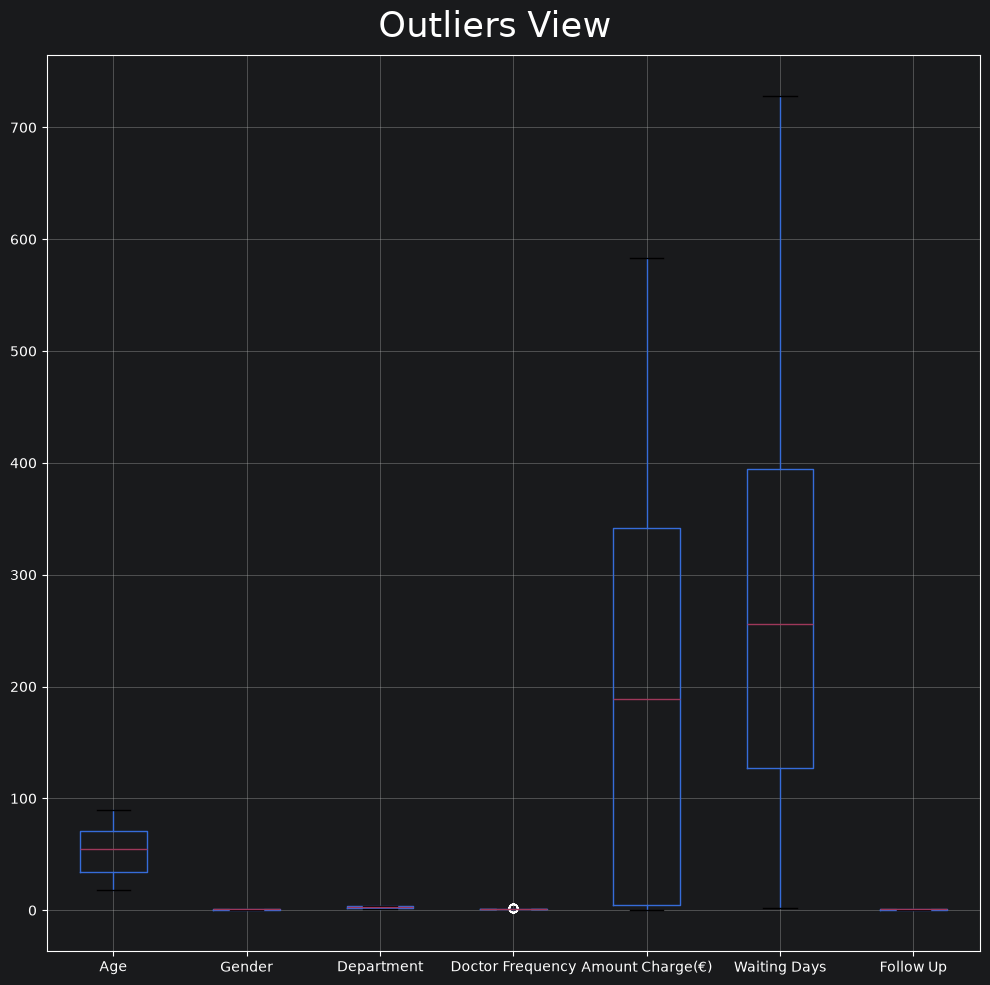

In [40]:
#Boxplot for outliers. change the background to white
plt.figure(figsize=(10,10))#Size of the plot.
clinic.boxplot()
plt.suptitle("Outliers View", fontsize=25)
plt.tight_layout()
plt.show();

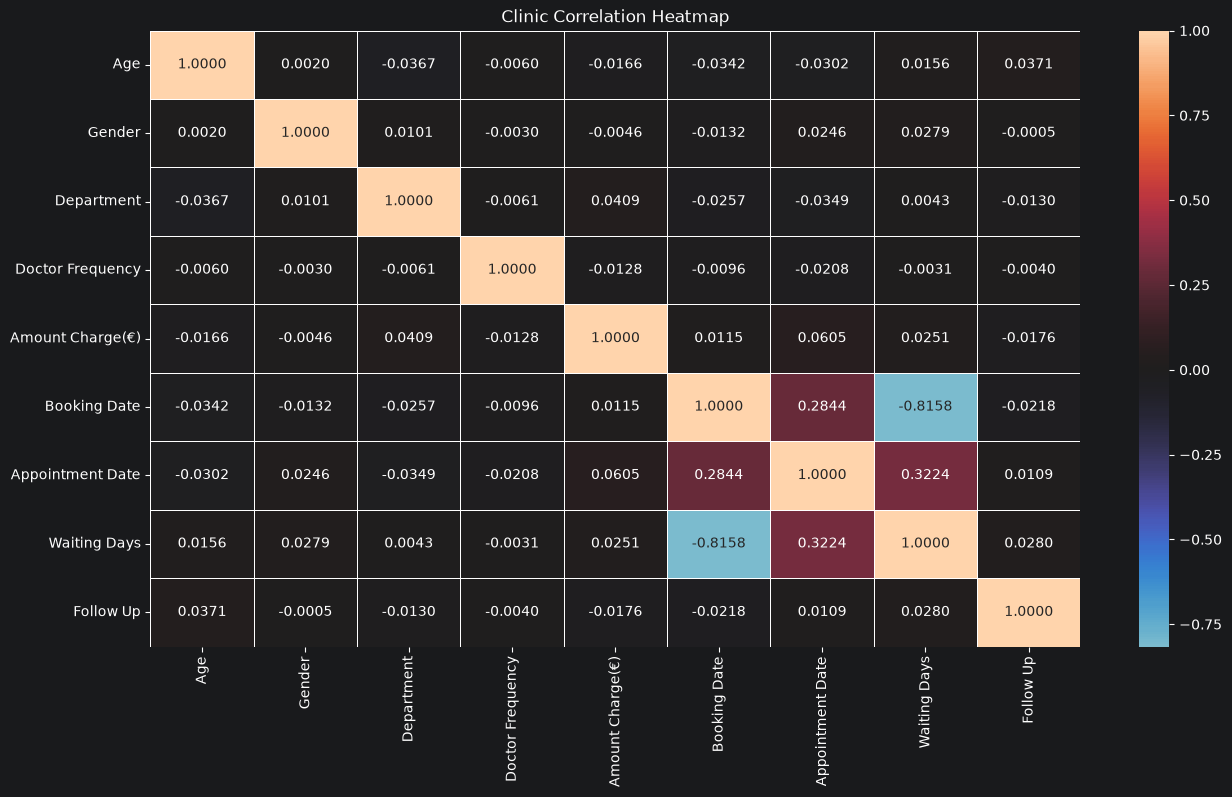

In [41]:
#Multivariant Analysis: correlation heatmap
clinic_heatmap = clinic.drop("Doctor", axis = 1).corr()
plt.figure(figsize=(15,8))
sns.heatmap(clinic_heatmap, annot=True, fmt='.4f', center=0,linewidths=.5)
plt.title('Clinic Correlation Heatmap')
plt.show();


In [42]:
#Pair-plot for visualization